In [56]:
import oracledb
import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
username = input("Enter Username : ")
userpwd = getpass.getpass(f"Enter password : ")
host = input("Enter Host : ") # "localhost"
port = 1521 #Assume Default port
service_name = input("Enter Service Name : ") # "freepdb1","database1"

In [ ]:
rep1 : pd.DataFrame
#Waiting implimentaion

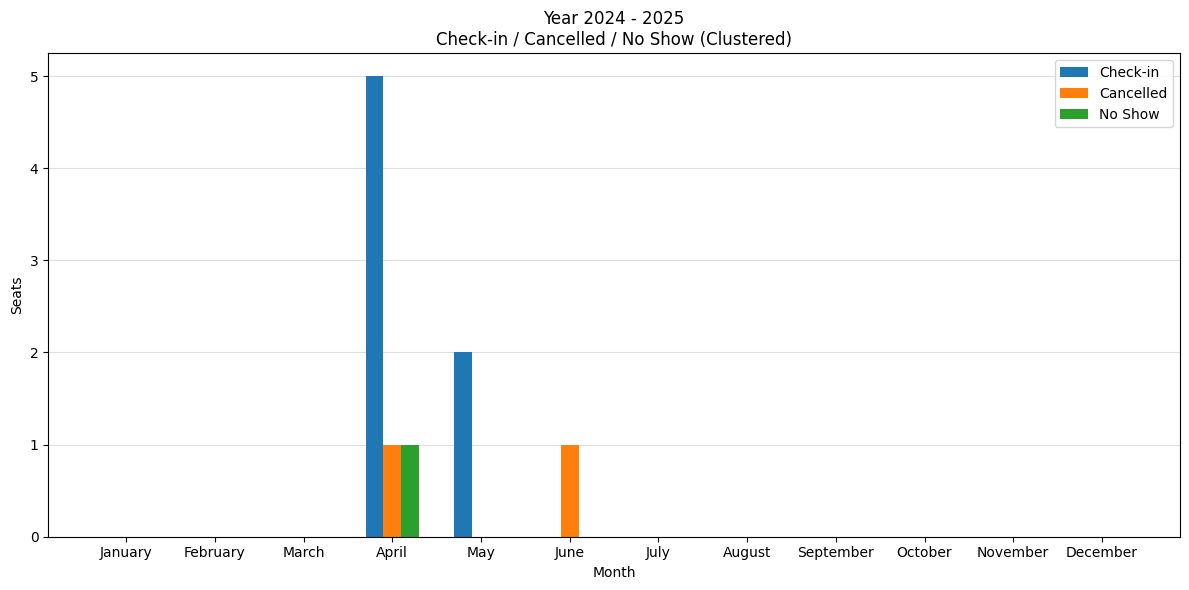

In [85]:
rep1 = pd.DataFrame(columns=["Month", "Bookings", "Seats", "Cancelled", "Checked-In", "No-Show"])

with oracledb.connect(f'{username}/{userpwd}@{host}:{port}/{service_name}') as connection :
    with connection.cursor() as cursor :
        year_s = input("Enter year : ")
        Year_Range = input("Enter range : ")
        query = cursor.execute(f'''
            SELECT
                TO_CHAR(M.MONTH_DATE, 'FMMonth') AS "Month",
                COUNT(BD."BID") AS "Booking Count",
                NVL(SUM(BD."SEAT"), 0) AS "Seat Booked",
                NVL(SUM(CASE
                    WHEN BD."CURRENT_STATUS" = '3' THEN BD."SEAT"
                    ELSE 0
                END), 0) AS "Cancelled",
                NVL(SUM(CASE
                    WHEN BD."CURRENT_STATUS" = '2' THEN BD."SEAT"
                    ELSE 0
                END), 0) AS "Checked-In",
                NVL(SUM(CASE
                    WHEN BD."CURRENT_STATUS" = '4' THEN BD."SEAT"
                    ELSE 0
                END), 0) AS "No-Show"
            FROM (
                    SELECT LEVEL AS MONTH_NO,
                           ADD_MONTHS(DATE '2025-01-01', LEVEL - 1) AS MONTH_DATE
                    FROM DUAL
                    CONNECT BY LEVEL <= 12
                ) M
                LEFT JOIN "BOOKING" B
                    ON EXTRACT(MONTH FROM B."DATE") = M.MONTH_NO
                   AND B."DATE" >= DATE '{year_s}-01-01'
                   AND B."DATE" <  DATE '{int(year_s) + int(Year_Range)}-01-01'
                LEFT JOIN "BOOKING_DETAIL" BD
                    ON B."BOOKING_ID" = BD."BID"
            GROUP BY
                M.MONTH_NO,
                M.MONTH_DATE
            ORDER BY
                M.MONTH_NO''')
        for _ in query : 
            rep1.loc[len(rep1)] = _

x = np.arange(len(rep1))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, rep1["Checked-In"], width, label="Check-in")
ax.bar(x,         rep1["Cancelled"],  width, label="Cancelled")
ax.bar(x + width, rep1["No-Show"],    width, label="No Show")

ax.set_xticks(x)
ax.set_xticklabels(rep1["Month"])

ax.set_xlabel("Month")
ax.set_ylabel("Seats")

if Year_Range == '1' :
    ax.set_title(f"Year {year_s}\nCheck-in / Cancelled / No Show (Clustered)")
else : 
    ax.set_title(f"Year {year_s} - {int(year_s) + int(Year_Range) - 1}\nCheck-in / Cancelled / No Show (Clustered)")

ax.grid(axis="y", alpha=0.4)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()